In [3]:
!pip install lime xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import lime
import lime.lime_tabular

print("Imports done.")

Imports done.


In [16]:
df = pd.read_csv("cmi_module1_clean-1.csv")

# Drop columns - note the exact capitalization: Metabolic_Alarms_Count
X = df.drop(columns=["sii", "BIA_measured", "Metabolic_Alarms_Count"])
y = df["sii"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape:", df.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(f"\nIs 'Metabolic_Alarms_Count' in X? {'Yes' if 'Metabolic_Alarms_Count' in X.columns else 'No'}")
print(f"Number of features: {X.shape[1]}")

Shape: (8417, 32)
Train shape: (6733, 29)
Test shape: (1684, 29)

Is 'Metabolic_Alarms_Count' in X? No
Number of features: 29


xgb regressor gridsearch

In [17]:
param_grid_xgbr = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgbr = XGBRegressor(random_state=42, eval_metric='rmse')
grid_xgbr = GridSearchCV(xgbr, param_grid_xgbr, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_xgbr.fit(X_train, y_train)

print("Best params:", grid_xgbr.best_params_)
print("Best CV R2:", round(grid_xgbr.best_score_, 4))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV R2: 0.1429


Evaluate

In [18]:
best_xgbr = grid_xgbr.best_estimator_

y_pred_xgbr = best_xgbr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgbr)
mse = mean_squared_error(y_test, y_pred_xgbr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgbr)

print("XGBoost Regressor — Test Set Results:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

XGBoost Regressor — Test Set Results:
MAE:  0.5250
MSE:  0.4567
RMSE: 0.6758
R2:   0.1420


features importance

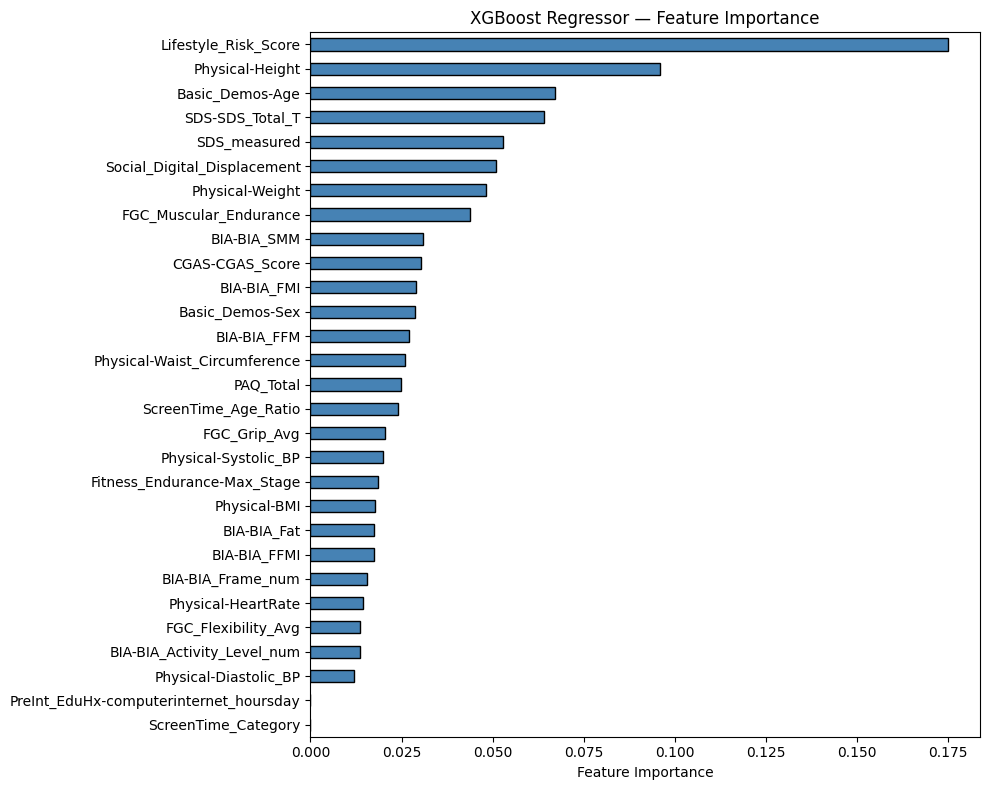


Top 10 most important features:
Lifestyle_Risk_Score           0.1751
Physical-Height                0.0960
Basic_Demos-Age                0.0671
SDS-SDS_Total_T                0.0642
SDS_measured                   0.0529
Social_Digital_Displacement    0.0510
Physical-Weight                0.0483
FGC_Muscular_Endurance         0.0437
BIA-BIA_SMM                    0.0309
CGAS-CGAS_Score                0.0304
dtype: float32


In [19]:
xgbr_importance = pd.Series(
    best_xgbr.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
xgbr_importance.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel("Feature Importance")
plt.title("XGBoost Regressor — Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(xgbr_importance.head(10).round(4))

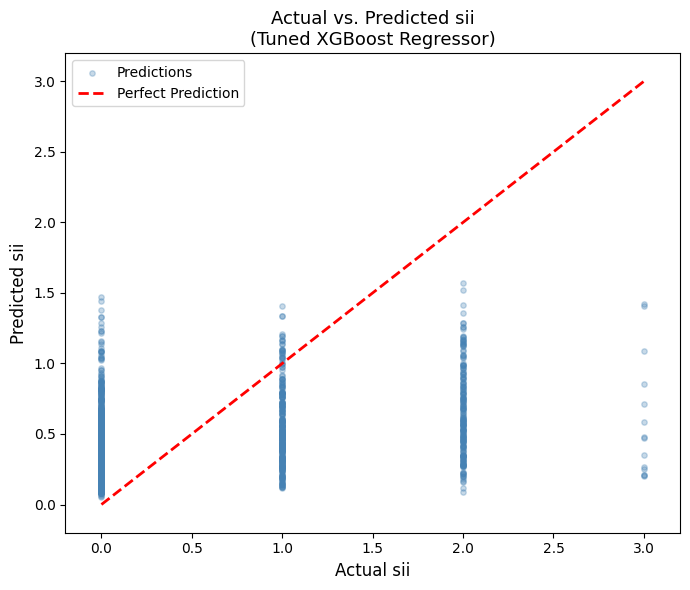

In [8]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred_xgbr, alpha=0.3, color='steelblue', s=15, label='Predictions')
plt.plot([0, 3], [0, 3], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel("Actual sii", fontsize=12)
plt.ylabel("Predicted sii", fontsize=12)
plt.title("Actual vs. Predicted sii\n(Tuned XGBoost Regressor)", fontsize=13)
plt.xlim(-0.2, 3.2)
plt.ylim(-0.2, 3.2)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

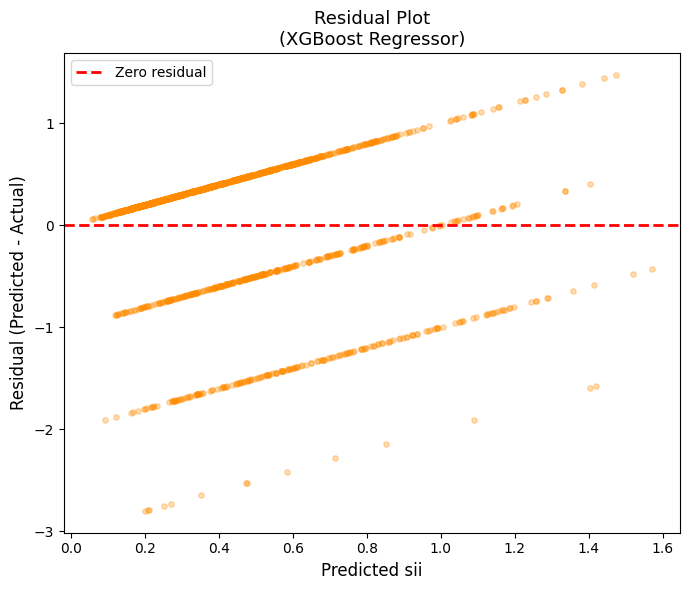

Mean Residual: -0.0063
Std Residual:  0.6757


In [9]:
# Residual Plot — XGBoost Regressor
residuals = y_pred_xgbr - y_test.values

plt.figure(figsize=(7, 6))
plt.scatter(y_pred_xgbr, residuals, alpha=0.3, color='darkorange', s=15)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero residual')
plt.xlabel("Predicted sii", fontsize=12)
plt.ylabel("Residual (Predicted - Actual)", fontsize=12)
plt.title("Residual Plot\n(XGBoost Regressor)", fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Residual:  {residuals.std():.4f}")

LIME

In [10]:
explainer_lime_reg = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode='regression',
    random_state=42
)

print("LIME Regressor explainer created successfully.")

LIME Regressor explainer created successfully.


Actual sii: 0.0
XGBoost predicted: 0.3753

Top 10 features explaining this prediction:
  SDS-SDS_Total_T > 56.00: 0.1775
  Basic_Demos-Sex <= 0.00: 0.0724
  61.50 < CGAS-CGAS_Score <= 65.00: -0.0645
  Physical-Height <= 55.00: -0.0556
  Social_Digital_Displacement <= 0.00: -0.0554
  57.80 < Physical-Weight <= 77.00: -0.0310
  Fitness_Endurance-Max_Stage <= 5.00: 0.0290
  Basic_Demos-Age <= 7.00: -0.0281
  52.55 < BIA-BIA_FFM <= 61.07: -0.0263
  0.98 < Lifestyle_Risk_Score <= 1.08: 0.0247


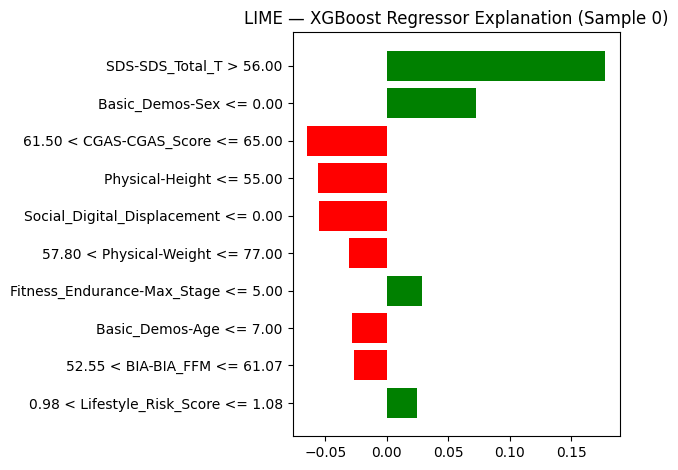

In [11]:
sample_idx = 0

explanation_reg = explainer_lime_reg.explain_instance(
    data_row=X_test.iloc[sample_idx].values,
    predict_fn=best_xgbr.predict,
    num_features=10
)

print(f"Actual sii: {y_test.iloc[sample_idx]}")
print(f"XGBoost predicted: {best_xgbr.predict(X_test.iloc[[sample_idx]])[0]:.4f}")
print(f"\nTop 10 features explaining this prediction:")
for feat, weight in explanation_reg.as_list():
    print(f"  {feat}: {weight:.4f}")

explanation_reg.as_pyplot_figure()
plt.title("LIME — XGBoost Regressor Explanation (Sample 0)")
plt.tight_layout()
plt.show()

Actual sii: 2.0
XGBoost predicted: 0.7399

Top 10 features:
  FGC_Muscular_Endurance > 8.50: 0.1012
  54.50 < SDS-SDS_Total_T <= 55.00: -0.0873
  0.88 < Lifestyle_Risk_Score <= 0.98: -0.0786
  BIA-BIA_FFM > 71.08: 0.0781
  Basic_Demos-Sex <= 0.00: 0.0667
  Basic_Demos-Age > 12.00: 0.0568
  77.00 < Physical-Weight <= 104.00: 0.0554
  BIA-BIA_SMM > 34.66: 0.0432
  CGAS-CGAS_Score <= 61.50: 0.0349
  Fitness_Endurance-Max_Stage <= 5.00: 0.0253


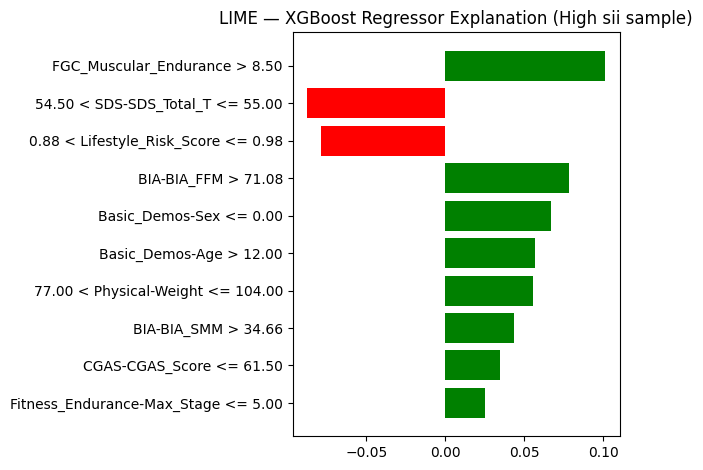

In [12]:
# Find a high sii sample
high_idx = y_test[y_test >= 2].index[0]
sample_pos = X_test.index.get_loc(high_idx)

explanation_reg2 = explainer_lime_reg.explain_instance(
    data_row=X_test.iloc[sample_pos].values,
    predict_fn=best_xgbr.predict,
    num_features=10
)

print(f"Actual sii: {y_test.iloc[sample_pos]}")
print(f"XGBoost predicted: {best_xgbr.predict(X_test.iloc[[sample_pos]])[0]:.4f}")
print(f"\nTop 10 features:")
for feat, weight in explanation_reg2.as_list():
    print(f"  {feat}: {weight:.4f}")

explanation_reg2.as_pyplot_figure()
plt.title("LIME — XGBoost Regressor Explanation (High sii sample)")
plt.tight_layout()
plt.show()